# Metric — Per-Persona Rank Correlation Between Methods

Spearman rank correlation $\rho$ between the **per-persona satisfaction rates**
of two methods (`scipy.stats.spearmanr`).

Computed for centralised-vs-federated pairs of the same objective, and for the
draft-revision model against each other method, to test whether methods rank
personas in the same order rather than merely scoring the same on average.

---

*Notation:* `q` query · `c+` relevant snippet · `c-` off-topic snippet from the same user · `y+` personalised answer · `y-` general answer


In [32]:
import sys
from pathlib import Path

import pandas as pd

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    PP_ROOT = Path("/content/drive/MyDrive") / "privacy_perserving_pllm"
else:
    _here = Path(".").resolve()
    PP_ROOT = next(
        (
            p
            for p in [_here, *_here.parents]
            if (p / "v2_personamem_persona_subsets").exists()
            or all((p / d).exists() for d in ("centralised", "evaluation", "fed_grad_avg", "zero_shot"))
        ),
        _here,
    )

SUBSETS_DIR = PP_ROOT / "v2_personamem_persona_subsets"
CATEGORY_COL = "topic_query"

SUBSETS = ["all_subset"]
MODELS = [
    "centralized_sft",
    "centralized_orpo",
    "centralized_ctx_contrast_orpo",
    "centralized_combined_orpo",
    "centralized_gen_edit_snippet",
    "federated_sft_gradavg",
    "federated_orpo_gradavg",
    "federated_ctx_contrast_orpo_gradavg",
    "federated_combined_orpo_gradavg",
    "federated_gen_edit_gradavg_snippet",
]

DISPLAY_NAMES = {
    "centralized_sft": "SFT",
    "centralized_orpo": "Answer-contrastive",
    "centralized_ctx_contrast_orpo": "Context-contrastive",
    "centralized_combined_orpo": "Dual-contrastive",
    "centralized_gen_edit_snippet": "Draft-revision",
    "federated_sft_gradavg": "SFT",
    "federated_orpo_gradavg": "Answer-contrastive",
    "federated_ctx_contrast_orpo_gradavg": "Context-contrastive",
    "federated_combined_orpo_gradavg": "Dual-contrastive",
    "federated_gen_edit_gradavg_snippet": "Draft-revision",
}

def display_name(model):
    prefix = ""
    if "centralized" in model:
        prefix = "Centralized "
    elif "federated" in model:
        prefix = "Federated "
    return prefix + DISPLAY_NAMES.get(model, model)

JUDGE_EVAL_DIR = "v2_personamem_llm_judge_pref_deepseek"
ADAPTER_EPOCH = 3
SPLIT = "val"
MODEL_PAIRS = [
    ("sft", "centralized_sft", "federated_sft_gradavg"),
    ("orpo", "centralized_orpo", "federated_orpo_gradavg"),
    ("ctx_contrast_orpo", "centralized_ctx_contrast_orpo", "federated_ctx_contrast_orpo_gradavg"),
    ("combined_orpo", "centralized_combined_orpo", "federated_combined_orpo_gradavg"),
    ("gen_edit", "centralized_gen_edit_snippet", "federated_gen_edit_gradavg_snippet"),
]

GEN_EDIT_MODELS = [
    "centralized_gen_edit_snippet",
    "federated_gen_edit_gradavg_snippet",
]

OUTPUT_DIR = PP_ROOT / "persona_sat_rank_correlation_deepseek"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PP_ROOT:", PP_ROOT)
print("Subsets:", SUBSETS)
print("Models:", MODELS)
print("Output:", OUTPUT_DIR.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PP_ROOT: /content/drive/MyDrive/privacy_perserving_pllm
Subsets: ['all_subset']
Models: ['centralized_sft', 'centralized_orpo', 'centralized_ctx_contrast_orpo', 'centralized_combined_orpo', 'centralized_gen_edit_snippet', 'federated_sft_gradavg', 'federated_orpo_gradavg', 'federated_ctx_contrast_orpo_gradavg', 'federated_combined_orpo_gradavg', 'federated_gen_edit_gradavg_snippet']
Output: /content/drive/MyDrive/privacy_perserving_pllm/persona_sat_rank_correlation_deepseek


In [2]:
def to_binary(series):
    if series.dtype == bool:
        return series.astype(float)
    s = series.astype(str).str.strip().str.lower()
    return s.map(
        {"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0, "1.0": 1.0, "0.0": 0.0}
    ).astype(float)


def judge_dir_for(subset):
    """Prefer epoch_<ADAPTER_EPOCH> if present; else the base DeepSeek judge dir."""
    base = PP_ROOT / subset / JUDGE_EVAL_DIR
    candidates = []
    if ADAPTER_EPOCH is not None:
        candidates.append(base / f"epoch_{ADAPTER_EPOCH}")
    candidates.append(base)
    for d in candidates:
        if d.is_dir():
            return d
    return None


def judge_csv_path(subset, model):
    jdir = judge_dir_for(subset)
    if jdir is None:
        return None
    candidates = [
        jdir / f"{model}_{SPLIT}_judge_run2.csv",
        jdir / f"{model}_{SPLIT}_judge.csv",
    ]
    return next((c for c in candidates if c.exists()), None)


_val_cat_cache: dict[str, pd.DataFrame] = {}


def load_val_category_lookup(subset):
    """persona_id, ex_id, topic_query from val.parquet."""
    if subset in _val_cat_cache:
        return _val_cat_cache[subset]
    path = SUBSETS_DIR / subset / "val.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}")
    va = pd.read_parquet(path)
    if CATEGORY_COL not in va.columns:
        raise ValueError(f"{path} missing column {CATEGORY_COL}; have {list(va.columns)}")
    parts = []
    for _, g in va.groupby("persona_id", sort=False):
        g = g.reset_index(drop=True).assign(ex_id=range(len(g)))
        parts.append(g[["persona_id", "ex_id", CATEGORY_COL]])
    out = pd.concat(parts, ignore_index=True)
    out["persona_id"] = out["persona_id"].astype(str)
    _val_cat_cache[subset] = out
    return out


def with_topic_query(df, subset):
    """Attach topic_query from the row or val.parquet lookup."""
    out = df.copy()
    out["persona_id"] = out["persona_id"].astype(str)
    if CATEGORY_COL in out.columns:
        return out
    if "ex_id" not in out.columns:
        print(f"  [category] cannot recover {CATEGORY_COL} without ex_id")
        return out
    look = load_val_category_lookup(subset)
    return out.merge(look, on=["persona_id", "ex_id"], how="left")


def load_judge_rows(subset, model):
    """Row-level judge output with satisfies + topic_query."""
    path = judge_csv_path(subset, model)
    if path is None:
        print(f"  [judge] missing judge CSV for {subset}/{model}")
        return None
    df = pd.read_csv(path)
    if "judge_satisfies_pref" not in df.columns or "persona_id" not in df.columns:
        print(f"  [judge] bad columns in {path.name}")
        return None
    df = with_topic_query(df, subset)
    if CATEGORY_COL not in df.columns:
        return None
    df = df.copy()
    df["satisfies"] = to_binary(df["judge_satisfies_pref"])
    df["subset"] = subset
    df["model"] = model
    return df

In [3]:
for subset in SUBSETS:
    jdir = judge_dir_for(subset)
    print(f"{subset}: judge_dir={jdir} | exists={jdir is not None and jdir.exists()}")
    if jdir is not None:
        sample = jdir / f"{MODELS[0]}_{SPLIT}_judge_run2.csv"
        print(f"  sample judge CSV: {sample.name} | exists={sample.exists()}")

all_subset: judge_dir=/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_llm_judge_pref_deepseek/epoch_3 | exists=True
  sample judge CSV: centralized_sft_val_judge_run2.csv | exists=True


In [4]:
def load_judge_sat_per_persona(subset, model):
    df = load_judge_rows(subset, model)
    if df is None or df.empty:
        return None
    g = (
        df.groupby("persona_id")["satisfies"]
        .mean()
        .reset_index()
        .rename(columns={"satisfies": "sat_rate"})
    )
    g["persona_id"] = g["persona_id"].astype(str)
    g["model"] = model
    return g[["persona_id", "model", "sat_rate"]]


metric_rows = []
for subset in SUBSETS:
    print(f"Loading per-persona sat rate for {subset} ...")
    for model in MODELS:
        mdf = load_judge_sat_per_persona(subset, model)
        if mdf is None or mdf.empty:
            continue
        mdf = mdf.copy()
        mdf.insert(0, "subset", subset)
        metric_rows.append(mdf)
        print(
            f"  {model}: personas={mdf['persona_id'].nunique()} | "
            f"mean sat={mdf['sat_rate'].mean():.3f}"
        )

per_persona = pd.concat(metric_rows, ignore_index=True) if metric_rows else pd.DataFrame()
if per_persona.empty:
    raise RuntimeError("No per-persona sat rates loaded. Check judge paths.")

per_persona = per_persona.sort_values(["subset", "model", "persona_id"]).reset_index(drop=True)
per_persona_path = OUTPUT_DIR / "per_persona_sat_metrics.csv"
per_persona.to_csv(per_persona_path, index=False)
print(f"\nSaved {len(per_persona):,} rows -> {per_persona_path}")
per_persona.head(10)

Loading per-persona sat rate for all_subset ...
  centralized_sft: personas=150 | mean sat=0.413
  centralized_orpo: personas=150 | mean sat=0.403
  centralized_ctx_contrast_orpo: personas=150 | mean sat=0.415
  centralized_combined_orpo: personas=150 | mean sat=0.435
  centralized_gen_edit_snippet: personas=150 | mean sat=0.470
  federated_sft_gradavg: personas=150 | mean sat=0.382
  federated_orpo_gradavg: personas=150 | mean sat=0.353
  federated_ctx_contrast_orpo_gradavg: personas=150 | mean sat=0.356
  federated_combined_orpo_gradavg: personas=150 | mean sat=0.337
  federated_gen_edit_gradavg_snippet: personas=150 | mean sat=0.407

Saved 1,500 rows -> /content/drive/MyDrive/privacy_perserving_pllm/persona_sat_rank_correlation_deepseek/per_persona_sat_metrics.csv


,subset,persona_id,model,sat_rate
0,all_subset,105,centralized_combined_orpo,0.200000
1,all_subset,106,centralized_combined_orpo,0.500000
2,all_subset,109,centralized_combined_orpo,0.333333
3,all_subset,111,centralized_combined_orpo,0.250000
4,all_subset,112,centralized_combined_orpo,0.166667
5,all_subset,119,centralized_combined_orpo,0.200000
6,all_subset,121,centralized_combined_orpo,0.600000
7,all_subset,131,centralized_combined_orpo,0.333333
8,all_subset,133,centralized_combined_orpo,0.500000
9,all_subset,135,centralized_combined_orpo,0.250000


In [5]:
category_rows = []
for subset in SUBSETS:
    print(f"Loading category sat rates for {subset} ...")
    for model in MODELS:
        df = load_judge_rows(subset, model)
        if df is None or df.empty:
            continue
        sub = df.dropna(subset=[CATEGORY_COL, "satisfies"]).copy()
        if sub.empty:
            print(f"  [skip] {model}: no rows with {CATEGORY_COL}")
            continue
        g = (
            sub.groupby(CATEGORY_COL, as_index=False)
            .agg(sat_rate=("satisfies", "mean"), n_samples=("satisfies", "size"))
            .rename(columns={CATEGORY_COL: "topic_query"})
        )
        g.insert(0, "subset", subset)
        g.insert(1, "model", model)
        category_rows.append(g)
        print(
            f"  {model}: categories={len(g)} | total n={int(g['n_samples'].sum())} | "
            f"mean sat={g['sat_rate'].mean():.3f}"
        )

by_category = pd.concat(category_rows, ignore_index=True) if category_rows else pd.DataFrame()
if by_category.empty:
    raise RuntimeError(f"No category sat rates loaded. Check judge paths / {CATEGORY_COL}.")

by_category = by_category.sort_values(
    ["subset", "model", "topic_query"]
).reset_index(drop=True)
by_category_path = OUTPUT_DIR / "sat_rate_by_topic_query.csv"
by_category.to_csv(by_category_path, index=False)
print(f"\nSaved {len(by_category):,} rows -> {by_category_path}")

print("\n=== Sample: sat rate by topic_query (first model) ===")
sample = by_category[by_category["model"] == MODELS[0]].head(12)
print(sample.round(4).to_string(index=False))

Loading category sat rates for all_subset ...
  centralized_sft: categories=143 | total n=714 | mean sat=0.476
  centralized_orpo: categories=143 | total n=714 | mean sat=0.441
  centralized_ctx_contrast_orpo: categories=143 | total n=714 | mean sat=0.484
  centralized_combined_orpo: categories=143 | total n=714 | mean sat=0.476
  centralized_gen_edit_snippet: categories=143 | total n=714 | mean sat=0.504
  federated_sft_gradavg: categories=143 | total n=714 | mean sat=0.424
  federated_orpo_gradavg: categories=143 | total n=714 | mean sat=0.399
  federated_ctx_contrast_orpo_gradavg: categories=143 | total n=714 | mean sat=0.458
  federated_combined_orpo_gradavg: categories=143 | total n=714 | mean sat=0.391
  federated_gen_edit_gradavg_snippet: categories=143 | total n=714 | mean sat=0.466

Saved 1,430 rows -> /content/drive/MyDrive/privacy_perserving_pllm/persona_sat_rank_correlation_deepseek/sat_rate_by_topic_query.csv

=== Sample: sat rate by topic_query (first model) ===
    subse

In [6]:
from scipy.stats import spearmanr

ranked = per_persona.copy()
ranked["sat_rate_rank"] = (
    ranked.groupby(["subset", "model"])["sat_rate"]
    .rank(ascending=False, method="average")
)

ranked_path = OUTPUT_DIR / "per_persona_sat_ranks.csv"
ranked.to_csv(ranked_path, index=False)
print("Saved:", ranked_path)

print("\n=== Top-5 personas by sat rate (all_subset, sample models) ===")
for model in MODELS[:3]:
    sub = ranked[(ranked["subset"] == SUBSETS[0]) & (ranked["model"] == model)]
    if sub.empty:
        continue
    top = sub.nsmallest(5, "sat_rate_rank")[["persona_id", "sat_rate", "sat_rate_rank"]]
    print(f"\n{display_name(model)} ({model}):")
    print(top.round(4).to_string(index=False))

def spearman_pair(dsub, model_a, model_b, metric="sat_rate"):
    a = dsub[dsub["model"] == model_a][["persona_id", metric]].dropna()
    b = dsub[dsub["model"] == model_b][["persona_id", metric]].dropna()
    if a.empty or b.empty:
        return None
    j = a.merge(b, on="persona_id", suffixes=("_a", "_b"))
    if len(j) < 3:
        return (float("nan"), float("nan"), len(j))
    rho, p = spearmanr(j[f"{metric}_a"], j[f"{metric}_b"])
    return (float(rho), float(p), len(j))

cent_fed_rows = []
for subset in SUBSETS:
    dsub = per_persona[per_persona["subset"] == subset]
    for family, cent_key, fed_key in MODEL_PAIRS:
        res = spearman_pair(dsub, cent_key, fed_key, metric="sat_rate")
        if res is None:
            continue
        rho, p, n = res
        cent_fed_rows.append(
            {
                "subset": subset,
                "family": family,
                "centralized_model": cent_key,
                "federated_model": fed_key,
                "metric": "sat_rate",
                "n_personas": n,
                "spearman_rho": rho,
                "p_value": p,
            }
        )

cent_fed_df = pd.DataFrame(cent_fed_rows)
cent_fed_path = OUTPUT_DIR / "spearman_cent_vs_fed_sat_rate.csv"
cent_fed_df.to_csv(cent_fed_path, index=False)
print("\nSaved:", cent_fed_path)
if len(cent_fed_df):
    print("\n=== Spearman rho: centralized vs federated (sat rate) ===")
    print(cent_fed_df.round(4).to_string(index=False))
    pivot = cent_fed_df.pivot(index="family", columns="subset", values="spearman_rho")
    print("\nPivot (rows=family, cols=subset):")
    print(pivot.round(3).to_string())

other_models = [m for m in MODELS if m not in GEN_EDIT_MODELS]
gen_edit_rows = []
for subset in SUBSETS:
    dsub = per_persona[per_persona["subset"] == subset]
    for gen_model in GEN_EDIT_MODELS:
        for other in other_models:
            res = spearman_pair(dsub, gen_model, other, metric="sat_rate")
            if res is None:
                continue
            rho, p, n = res
            gen_edit_rows.append(
                {
                    "subset": subset,
                    "gen_edit_model": gen_model,
                    "other_model": other,
                    "metric": "sat_rate",
                    "n_personas": n,
                    "spearman_rho": rho,
                    "p_value": p,
                }
            )

gen_edit_df = pd.DataFrame(gen_edit_rows)
gen_edit_path = OUTPUT_DIR / "spearman_gen_edit_vs_others_sat_rate.csv"
gen_edit_df.to_csv(gen_edit_path, index=False)
print("\nSaved:", gen_edit_path)
if len(gen_edit_df):
    print("\n=== Spearman rho: gen_edit vs other models (sat rate) ===")
    for subset in SUBSETS:
        s = gen_edit_df[gen_edit_df["subset"] == subset]
        if s.empty:
            continue
        for gen_model in GEN_EDIT_MODELS:
            ss = s[s["gen_edit_model"] == gen_model].sort_values("spearman_rho", ascending=False)
            if ss.empty:
                continue
            print(f"\n{subset} | {display_name(gen_model)} ({gen_model}) vs others:")
            show = ss[["other_model", "n_personas", "spearman_rho", "p_value"]].copy()
            show["other_model"] = show["other_model"].map(lambda m: f"{display_name(m)} ({m})")
            print(show.round(4).to_string(index=False))

    for subset in SUBSETS:
        s = gen_edit_df[gen_edit_df["subset"] == subset]
        if s.empty:
            continue
        print(f"\n### {subset} pivot: gen_edit vs other models")
        for gen_model in GEN_EDIT_MODELS:
            ss = s[s["gen_edit_model"] == gen_model]
            if ss.empty:
                continue
            pivot = ss.set_index("other_model")["spearman_rho"].reindex(other_models)
            pivot.index = [display_name(m) for m in pivot.index]
            print(f"\n{display_name(gen_model)}:")
            print(pivot.round(3).to_string())

Saved: /content/drive/MyDrive/privacy_perserving_pllm/persona_sat_rank_correlation_deepseek/per_persona_sat_ranks.csv

=== Top-5 personas by sat rate (all_subset, sample models) ===

SFT (centralized_sft):
persona_id  sat_rate  sat_rate_rank
       598    1.0000            2.5
       600    1.0000            2.5
       607    1.0000            2.5
       772    1.0000            2.5
       555    0.8333            5.0

Answer-contrastive (centralized_orpo):
persona_id  sat_rate  sat_rate_rank
       166       1.0            2.0
       607       1.0            2.0
       675       1.0            2.0
       119       0.8            5.5
       200       0.8            5.5

Context-contrastive (centralized_ctx_contrast_orpo):
persona_id  sat_rate  sat_rate_rank
       891    0.8571            1.0
       194    0.8000            5.5
       200    0.8000            5.5
       433    0.8000            5.5
       449    0.8000            5.5

Saved: /content/drive/MyDrive/privacy_perserving_pl

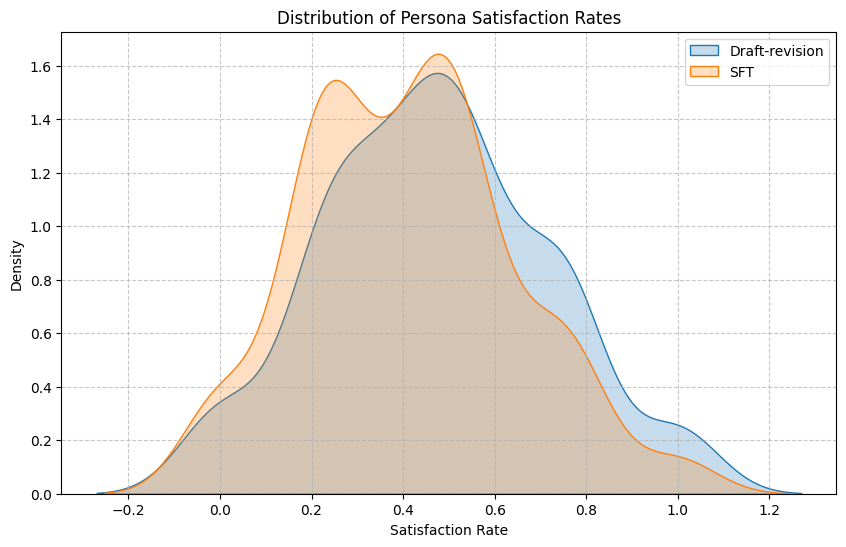

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

model_a = "centralized_gen_edit_snippet"
model_b = "centralized_sft"

df_a = per_persona[per_persona["model"] == model_a]
df_b = per_persona[per_persona["model"] == model_b]

plt.figure(figsize=(10, 6))
sns.kdeplot(df_a["sat_rate"], label=display_name(model_a), fill=True)
sns.kdeplot(df_b["sat_rate"], label=display_name(model_b), fill=True)

plt.title("Distribution of Persona Satisfaction Rates")
plt.xlabel("Satisfaction Rate")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

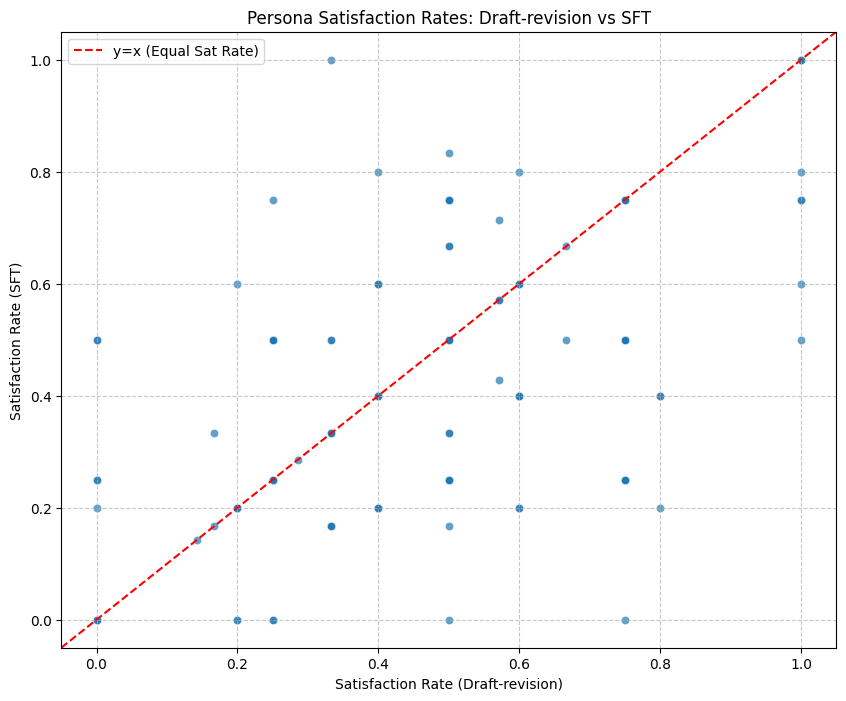

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

model_a_name = "centralized_gen_edit_snippet"
model_b_name = "centralized_sft"

df_model_a = per_persona[per_persona["model"] == model_a_name][["persona_id", "sat_rate"]].rename(columns={"sat_rate": "sat_rate_A"})
df_model_b = per_persona[per_persona["model"] == model_b_name][["persona_id", "sat_rate"]].rename(columns={"sat_rate": "sat_rate_B"})

merged_df = pd.merge(df_model_a, df_model_b, on="persona_id")

plt.figure(figsize=(10, 8))
sns.scatterplot(x="sat_rate_A", y="sat_rate_B", data=merged_df, alpha=0.7)

plt.title(f"Persona Satisfaction Rates: {display_name(model_a_name)} vs {display_name(model_b_name)}")
plt.xlabel(f"Satisfaction Rate ({display_name(model_a_name)})")
plt.ylabel(f"Satisfaction Rate ({display_name(model_b_name)})")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x (Equal Sat Rate)')
plt.legend()
plt.show()

In [15]:
better_sft_count = (merged_df['sat_rate_B'] > merged_df['sat_rate_A']).sum()

total_personas = len(merged_df)

percentage_better_sft = (better_sft_count / total_personas) * 100

print(f"Number of personas where {display_name(model_b_name)} has a higher satisfaction rate: {better_sft_count}")
print(f"Total number of personas: {total_personas}")
print(f"Percentage of personas where {display_name(model_b_name)} has a higher satisfaction rate than {display_name(model_a_name)}: {percentage_better_sft:.2f}%")

Number of personas where SFT has a higher satisfaction rate: 32
Total number of personas: 150
Percentage of personas where SFT has a higher satisfaction rate than Draft-revision: 21.33%


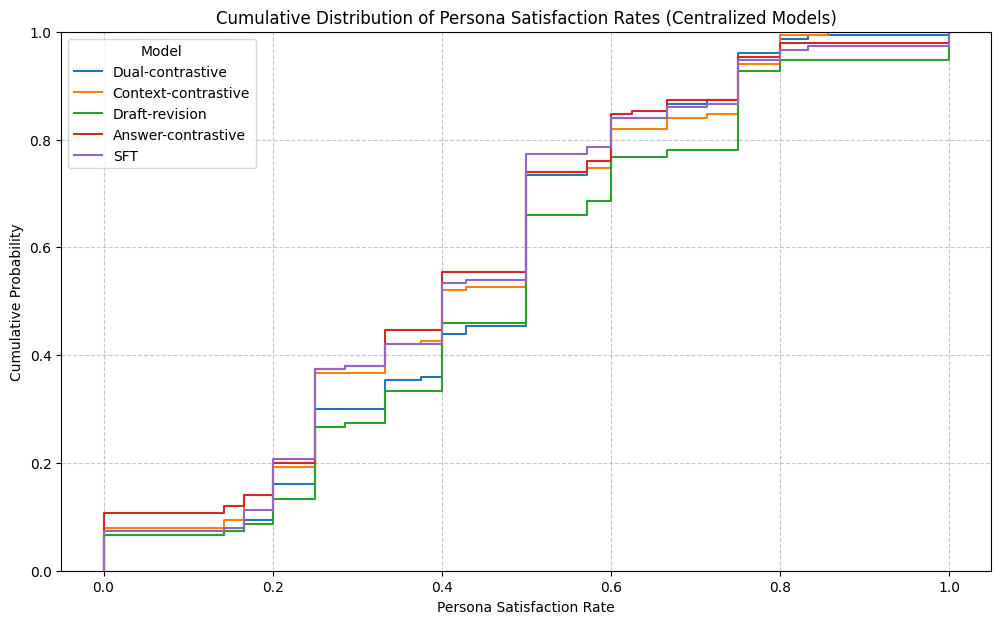

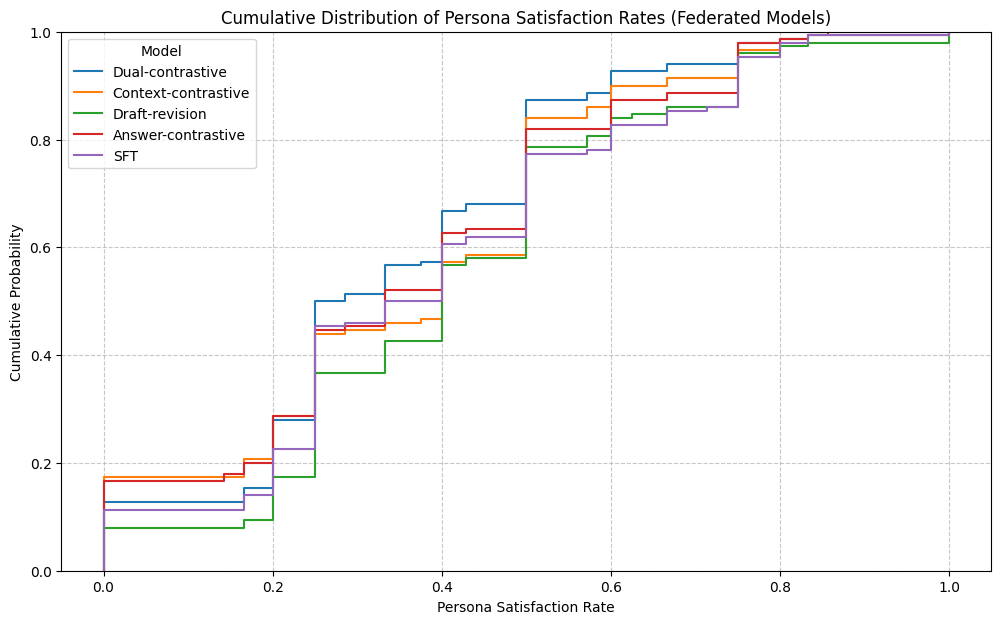

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
centralized_models_df = per_persona[per_persona['model'].str.contains('centralized')]

for model_name in centralized_models_df['model'].unique():
    model_df = centralized_models_df[centralized_models_df['model'] == model_name]
    sns.ecdfplot(data=model_df, x='sat_rate', label=display_name(model_name))

plt.title('Cumulative Distribution of Persona Satisfaction Rates (Centralized Models)')
plt.xlabel('Persona Satisfaction Rate')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()

plt.figure(figsize=(12, 7))
federated_models_df = per_persona[per_persona['model'].str.contains('federated')]

for model_name in federated_models_df['model'].unique():
    model_df = federated_models_df[federated_models_df['model'] == model_name]
    sns.ecdfplot(data=model_df, x='sat_rate', label=display_name(model_name))

plt.title('Cumulative Distribution of Persona Satisfaction Rates (Federated Models)')
plt.xlabel('Persona Satisfaction Rate')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()

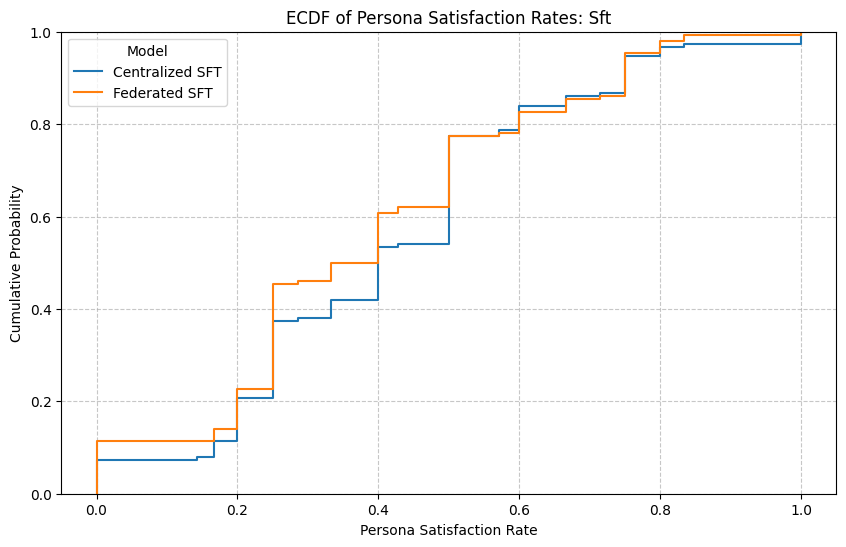

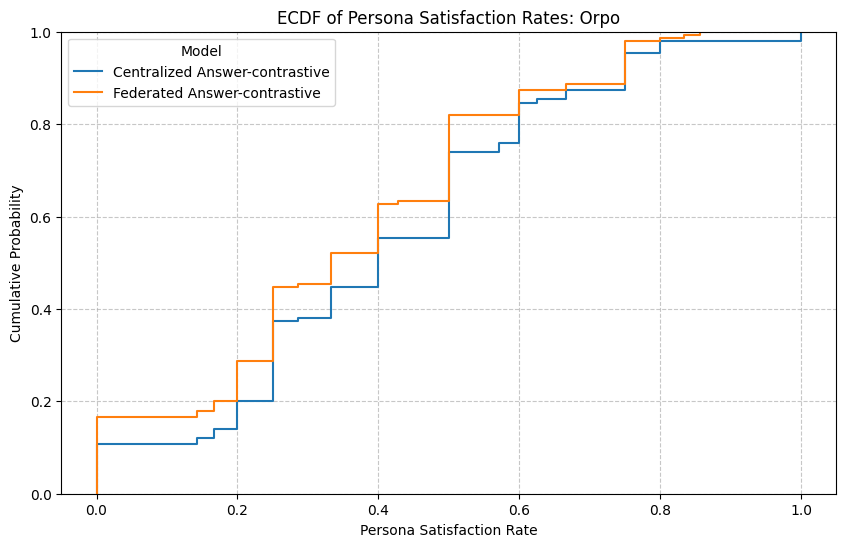

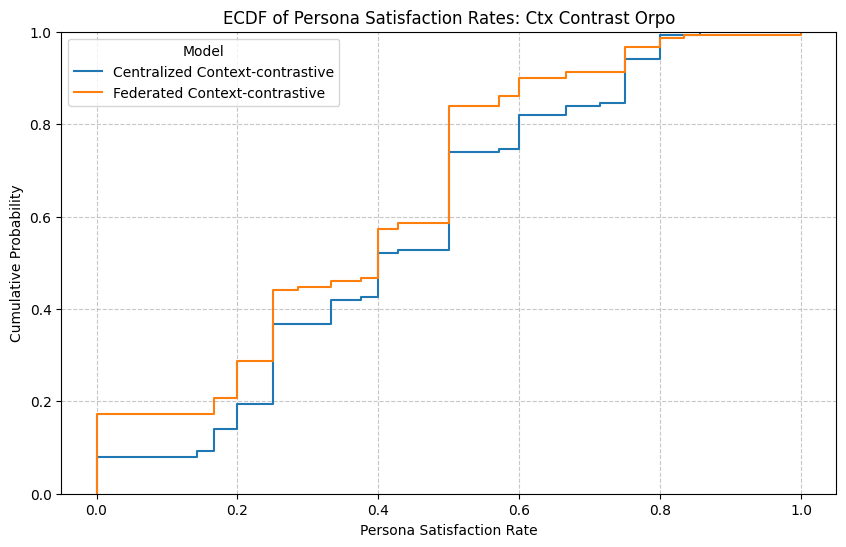

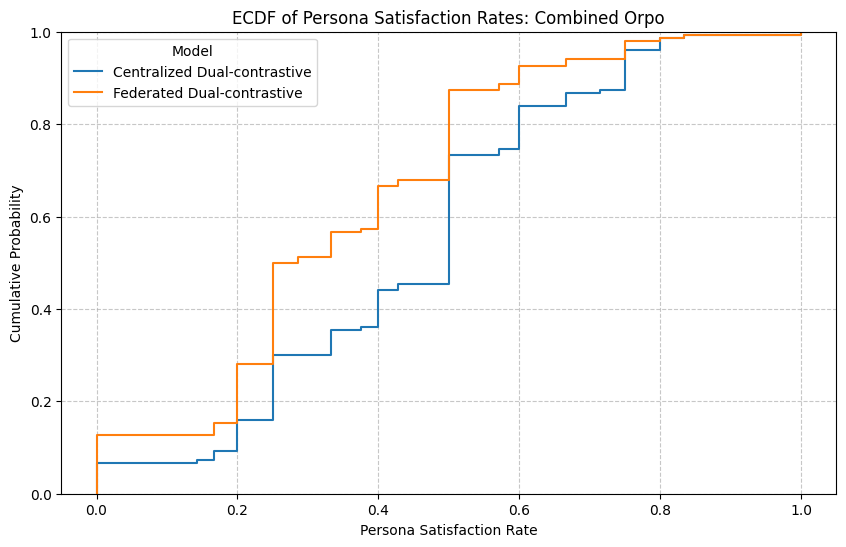

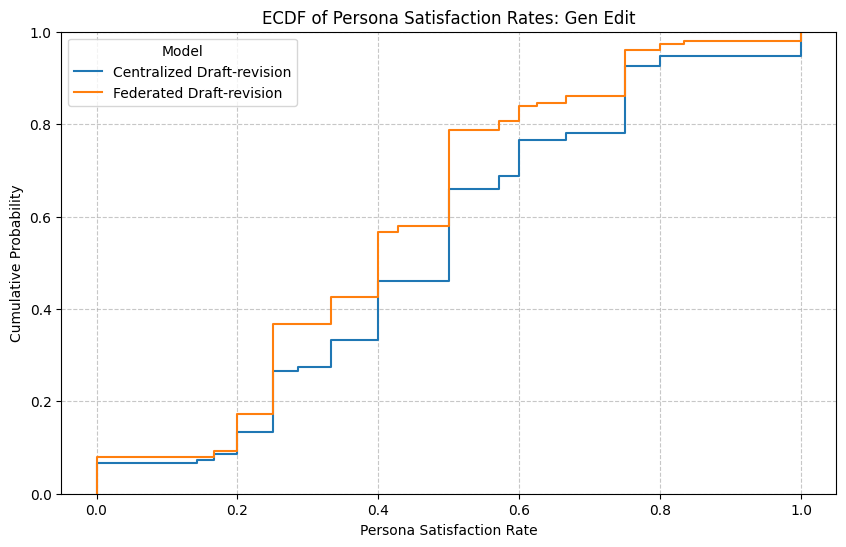

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

for family, cent_model, fed_model in MODEL_PAIRS:
    plt.figure(figsize=(10, 6))

    df_cent = per_persona[per_persona['model'] == cent_model]
    sns.ecdfplot(data=df_cent, x='sat_rate', label=f'Centralized {display_name(cent_model)}')

    df_fed = per_persona[per_persona['model'] == fed_model]
    sns.ecdfplot(data=df_fed, x='sat_rate', label=f'Federated {display_name(fed_model)}')

    plt.title(f'ECDF of Persona Satisfaction Rates: {family.replace("_", " ").title()}')
    plt.xlabel('Persona Satisfaction Rate')
    plt.ylabel('Cumulative Probability')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Model')
    plt.show()

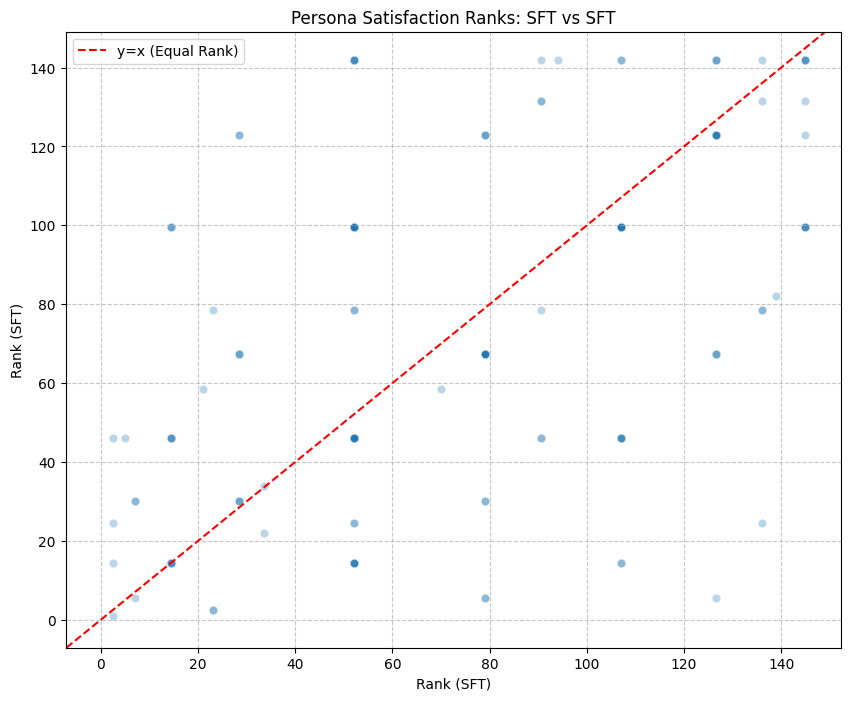

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

model_a_name_rank = "centralized_sft"

model_b_name_rank = "federated_sft_gradavg"

df_model_a_rank = ranked[ranked["model"] == model_a_name_rank][["persona_id", "sat_rate_rank"]].rename(columns={"sat_rate_rank": "rank_A"})
df_model_b_rank = ranked[ranked["model"] == model_b_name_rank][["persona_id", "sat_rate_rank"]].rename(columns={"sat_rate_rank": "rank_B"})

merged_ranks_df = pd.merge(df_model_a_rank, df_model_b_rank, on="persona_id")

plt.figure(figsize=(10, 8))
sns.scatterplot(x="rank_A", y="rank_B", data=merged_ranks_df, alpha=0.3)

plt.title(f"Persona Satisfaction Ranks: {display_name(model_a_name_rank)} vs {display_name(model_b_name_rank)}")
plt.xlabel(f"Rank ({display_name(model_a_name_rank)})")
plt.ylabel(f"Rank ({display_name(model_b_name_rank)})")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x (Equal Rank)')
plt.legend()
plt.show()

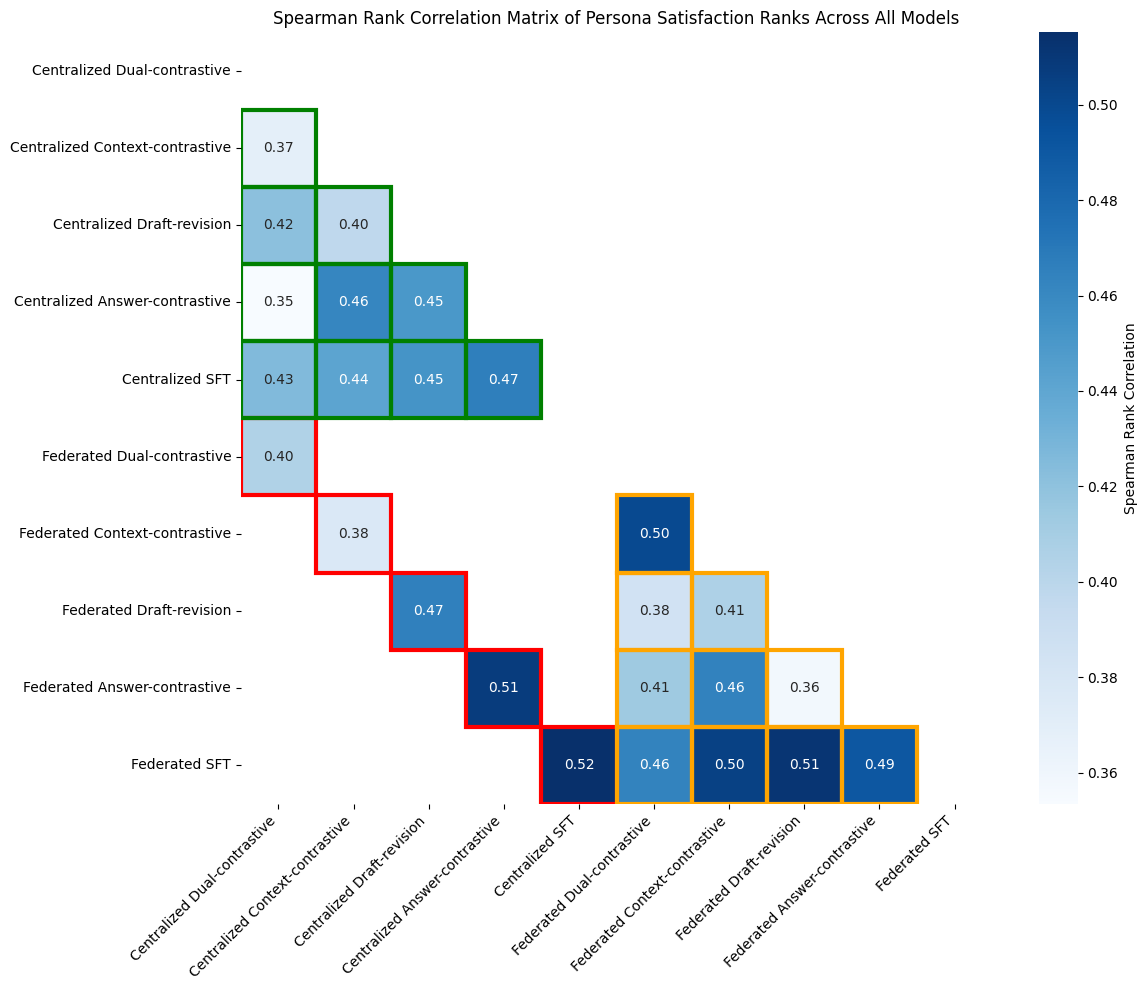

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as patches

rank_pivot = ranked.pivot_table(
    index='persona_id',
    columns='model',
    values='sat_rate_rank'
)

correlation_matrix = rank_pivot.corr(method='spearman')

np.fill_diagonal(correlation_matrix.values, np.nan)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
correlation_matrix = correlation_matrix.mask(mask)

original_model_cols = correlation_matrix.columns.tolist()
original_model_idx = correlation_matrix.index.tolist()

for r_idx, row_model in enumerate(original_model_idx):
    for c_idx, col_model in enumerate(original_model_cols):
        if r_idx > c_idx and not pd.isna(correlation_matrix.iloc[r_idx, c_idx]):
            is_row_centralized = "centralized" in row_model
            is_row_federated = "federated" in row_model
            is_col_centralized = "centralized" in col_model
            is_col_federated = "federated" in col_model

            if (is_row_centralized and is_col_federated) or (is_row_federated and is_col_centralized):
                is_matched_pair = False
                for _, cent_key, fed_key in MODEL_PAIRS:
                    if (row_model == cent_key and col_model == fed_key) or \
                       (row_model == fed_key and col_model == cent_key):
                        is_matched_pair = True
                        break

                if not is_matched_pair:
                    correlation_matrix.iloc[r_idx, c_idx] = np.nan

correlation_matrix.columns = [display_name(col) for col in original_model_cols]
correlation_matrix.index = [display_name(idx) for idx in original_model_idx]

def is_centralized_display_name(name):
    return name.startswith("Centralized ")

def is_federated_display_name(name):
    return name.startswith("Federated ")

CENT_FED_BORDER_COLOR = 'red'
CENT_CENT_BORDER_COLOR = 'green'
FED_FED_BORDER_COLOR = 'orange'
BORDER_LINEWIDTH = 3

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Spearman Rank Correlation'}
)

for family, cent_key, fed_key in MODEL_PAIRS:
    cent_display = display_name(cent_key)
    fed_display = display_name(fed_key)

    try:
        col_idx = list(correlation_matrix.columns).index(cent_display)
        row_idx = list(correlation_matrix.index).index(fed_display)

        if col_idx < row_idx and not pd.isna(correlation_matrix.loc[fed_display, cent_display]):
            rect = patches.Rectangle((col_idx, row_idx), 1, 1,
                                     fill=False, edgecolor=CENT_FED_BORDER_COLOR, lw=BORDER_LINEWIDTH)
            ax.add_patch(rect)
    except ValueError:
        print(f"Warning: Could not find display names for '{cent_key}' or '{fed_key}' in matrix axes. Skipping border for this pair.")

for r_idx, row_display_name in enumerate(correlation_matrix.index):
    for c_idx, col_display_name in enumerate(correlation_matrix.columns):
        if r_idx > c_idx and not pd.isna(correlation_matrix.iloc[r_idx, c_idx]):
            if is_centralized_display_name(row_display_name) and is_centralized_display_name(col_display_name):
                rect = patches.Rectangle((c_idx, r_idx), 1, 1,
                                         fill=False, edgecolor=CENT_CENT_BORDER_COLOR, lw=BORDER_LINEWIDTH)
                ax.add_patch(rect)

for r_idx, row_display_name in enumerate(correlation_matrix.index):
    for c_idx, col_display_name in enumerate(correlation_matrix.columns):
        if r_idx > c_idx and not pd.isna(correlation_matrix.iloc[r_idx, c_idx]):
            if is_federated_display_name(row_display_name) and is_federated_display_name(col_display_name):
                rect = patches.Rectangle((c_idx, r_idx), 1, 1,
                                         fill=False, edgecolor=FED_FED_BORDER_COLOR, lw=BORDER_LINEWIDTH)
                ax.add_patch(rect)

plt.title('Spearman Rank Correlation Matrix of Persona Satisfaction Ranks Across All Models')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

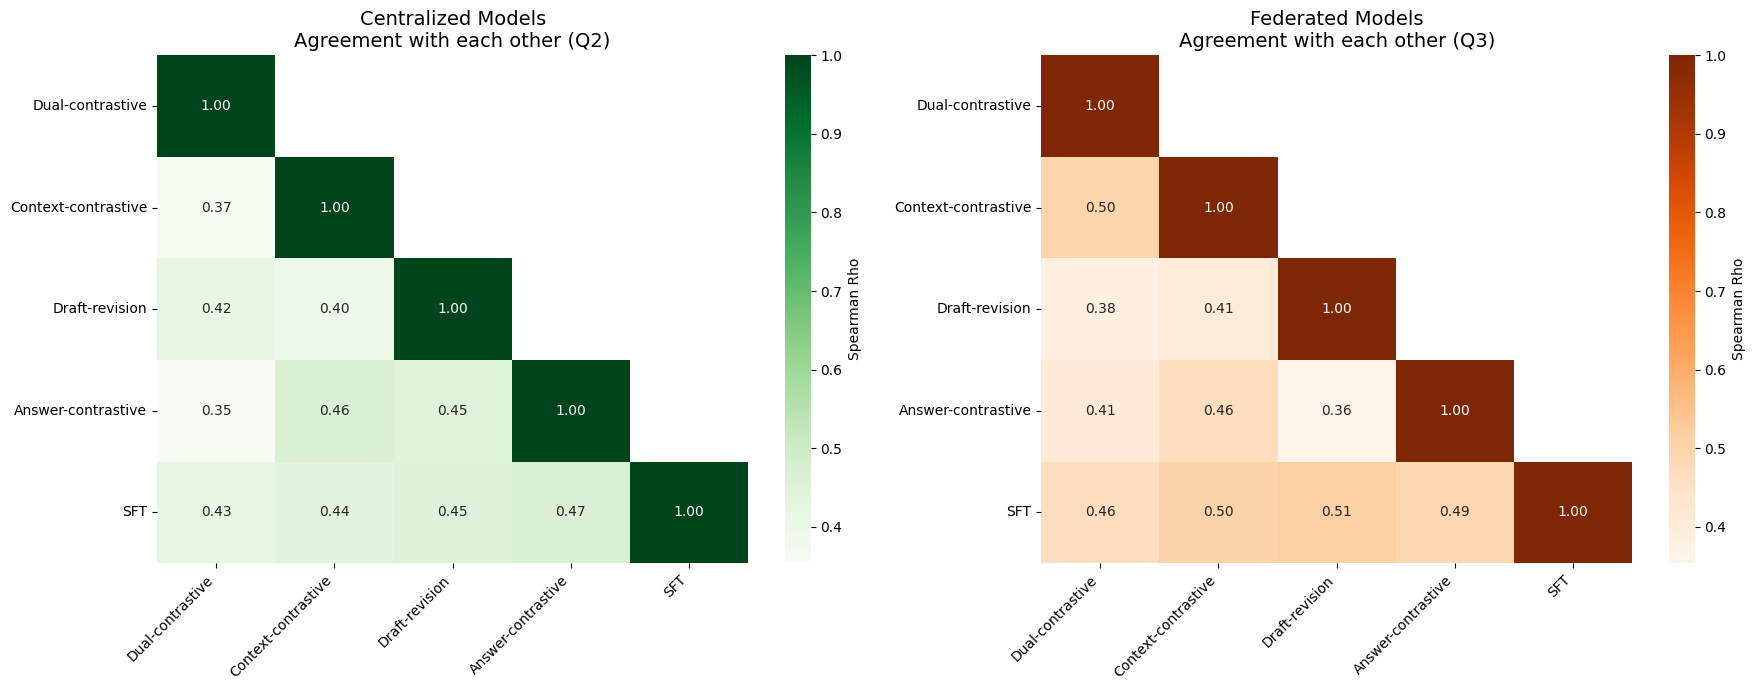

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

full_corr = rank_pivot.corr(method='spearman')

cent_cols = [col for col in full_corr.columns if 'centralized' in col]
fed_cols = [col for col in full_corr.columns if 'federated' in col]

corr_cent = full_corr.loc[cent_cols, cent_cols].copy()
corr_fed = full_corr.loc[fed_cols, fed_cols].copy()

short_names_cent = [display_name(c).replace("Centralized ", "") for c in cent_cols]
short_names_fed = [display_name(c).replace("Federated ", "") for c in fed_cols]
corr_cent.index = short_names_cent
corr_cent.columns = short_names_cent
corr_fed.index = short_names_fed
corr_fed.columns = short_names_fed

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

vmin = min(corr_cent.min().min(), corr_fed.min().min())
vmax = 1.0
mask_cent = np.triu(np.ones_like(corr_cent, dtype=bool), k=1)
mask_fed = np.triu(np.ones_like(corr_fed, dtype=bool), k=1)

sns.heatmap(corr_cent, annot=True, cmap='Greens', fmt=".2f", ax=axes[0],
            vmin=vmin, vmax=vmax, mask=mask_cent, cbar_kws={'label': 'Spearman Rho'})
axes[0].set_title('Centralized Models\nAgreement with each other (Q2)', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(corr_fed, annot=True, cmap='Oranges', fmt=".2f", ax=axes[1],
            vmin=vmin, vmax=vmax, mask=mask_fed, cbar_kws={'label': 'Spearman Rho'})
axes[1].set_title('Federated Models\nAgreement with each other (Q3)', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

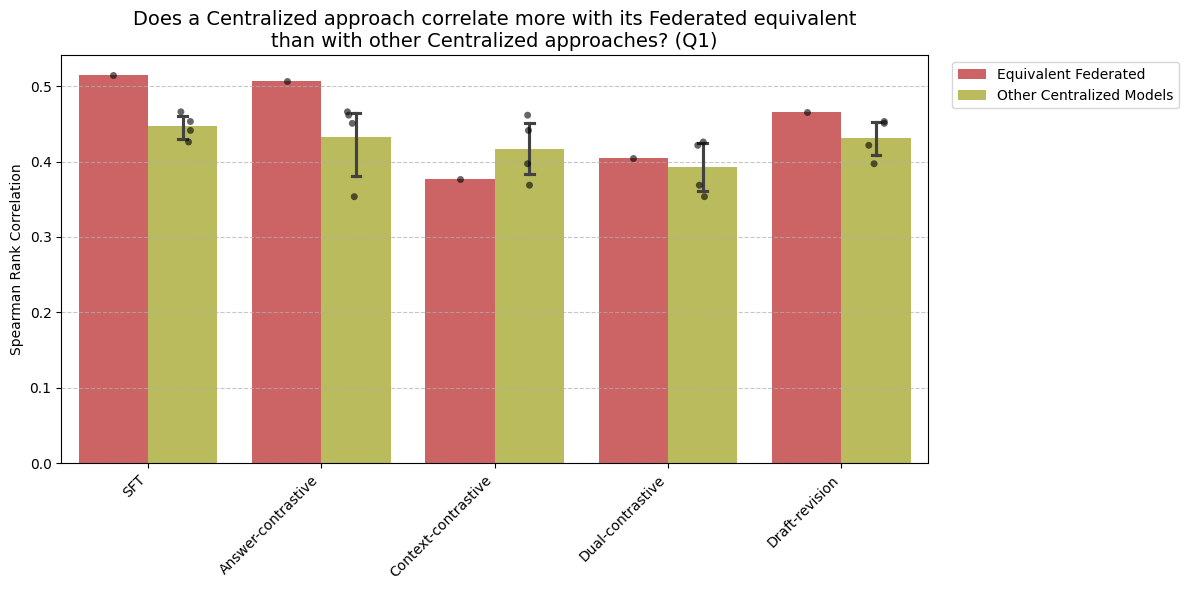

In [42]:
import pandas as pd

bar_data = []

for family, cent_key, fed_key in MODEL_PAIRS:
    display_fam = display_name(cent_key).replace("Centralized ", "")

    cent_fed_val = full_corr.loc[cent_key, fed_key]
    bar_data.append({
        'Base Centralized Model': display_fam,
        'Compared To': 'Equivalent Federated',
        'Correlation': cent_fed_val
    })

    for other_cent in cent_cols:
        if other_cent != cent_key:
            other_val = full_corr.loc[cent_key, other_cent]
            bar_data.append({
                'Base Centralized Model': display_fam,
                'Compared To': 'Other Centralized Models',
                'Correlation': other_val
            })

df_bar = pd.DataFrame(bar_data)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_bar,
    x='Base Centralized Model',
    y='Correlation',
    hue='Compared To',
    palette={'Equivalent Federated': '#d62728', 'Other Centralized Models': '#bcbd22'},
    capsize=0.1,
    alpha=0.8
)

sns.stripplot(
    data=df_bar,
    x='Base Centralized Model',
    y='Correlation',
    hue='Compared To',
    dodge=True,
    palette={'Equivalent Federated': 'black', 'Other Centralized Models': 'black'},
    alpha=0.6,
    jitter=0.1,
    legend=False
)

plt.title('Does a Centralized approach correlate more with its Federated equivalent\nthan with other Centralized approaches? (Q1)', fontsize=14)
plt.ylabel('Spearman Rank Correlation')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [24]:
df_model_a_rank

,persona_id,rank_A
600,105,28.5
601,106,145.0
602,109,52.0
603,111,52.0
604,112,136.0
...,...,...
745,975,52.0
746,980,90.5
747,987,79.0
748,99,28.5
